In [1]:
from pathlib import Path
from typing import Union
import numpy as np
import cv2
import matplotlib.pyplot as plt

try:
    import tifffile
except ImportError:
    tifffile = None


# =============================================================================
# Constants
# =============================================================================

TARGET_THETA_MRAD = 0.03169081573284781
NEGATIVE_TARGET_THETA_MRAD = -0.03169081573284781
LENS_HALF_HEIGHT_INCH = 0.25
LENS_HALF_HEIGHT_MM = LENS_HALF_HEIGHT_INCH * 25.4


# =============================================================================
# Image loading / writing
# =============================================================================

def load_gray_native(path: Union[str, Path]) -> np.ndarray:
    """
    Load a grayscale image without changing its stored bit depth.
    Returns uint8 or uint16 when possible.
    """
    p = Path(path)

    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)

    if img is None:
        if tifffile is None:
            raise IOError(
                f"Could not decode image with OpenCV, and tifffile is not installed: {p}"
            )
        img = tifffile.imread(str(p))

    img = np.asarray(img)

    if img.ndim == 3:
        if img.shape[2] == 1:
            img = img[:, :, 0]
        elif img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return img


def detect_storage_mode(img: np.ndarray) -> str:
    """
    Detect likely storage mode of the input image.

    Returns:
        '8bit'
        '12in16_shifted'   -> Phantom-style 12-bit values shifted left by 4
        '12in16_lowrange'  -> uint16 but only 0..4095 used
        '16bit'
    """
    if img.dtype == np.uint8:
        return "8bit"

    if img.dtype != np.uint16:
        raise ValueError(f"Unsupported dtype for detection: {img.dtype}")

    mx = int(img.max())

    if np.all((img & 15) == 0):
        return "12in16_shifted"

    if mx <= 4095:
        return "12in16_lowrange"

    return "16bit"


def storage_mode_info(mode: str) -> tuple[int, int]:
    """
    Return nominal bit depth and nominal max value.
    """
    if mode == "8bit":
        return 8, 255
    if mode == "12in16_shifted":
        return 12, 4095
    if mode == "12in16_lowrange":
        return 12, 4095
    if mode == "16bit":
        return 16, 65535
    raise ValueError(f"Unknown storage mode: {mode}")


def decode_to_nominal(img_native: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert stored image data into nominal processing space.

    Examples:
    - 8-bit stays 0..255
    - 12in16_shifted becomes 0..4095 by shifting right 4
    - 12in16_lowrange stays 0..4095
    - 16bit stays 0..65535
    """
    if mode == "8bit":
        return img_native.astype(np.float32)

    if mode == "12in16_shifted":
        return (img_native.astype(np.uint16) >> 4).astype(np.float32)

    if mode == "12in16_lowrange":
        return img_native.astype(np.float32)

    if mode == "16bit":
        return img_native.astype(np.float32)

    raise ValueError(f"Unknown storage mode: {mode}")


def encode_from_nominal(img_nominal: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert nominal-space data back into the same storage style as input.
    """
    nominal_bits, nominal_max = storage_mode_info(mode)
    arr = np.clip(np.round(img_nominal), 0, nominal_max)

    if mode == "8bit":
        return arr.astype(np.uint8)

    if mode == "12in16_shifted":
        return (arr.astype(np.uint16) << 4)

    if mode == "12in16_lowrange":
        return arr.astype(np.uint16)

    if mode == "16bit":
        return arr.astype(np.uint16)

    raise ValueError(f"Unknown storage mode: {mode}")


def load_gray_nominal(path: Union[str, Path]) -> tuple[np.ndarray, str]:
    """
    Load one image and return:
        nominal_image_float32, detected_storage_mode
    """
    native = load_gray_native(path)
    mode = detect_storage_mode(native)
    nominal = decode_to_nominal(native, mode)
    return nominal, mode


def write_image_same_storage(path: Union[str, Path], img_nominal: np.ndarray, mode: str):
    """
    Save an image using the same storage style as the input.
    """
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)

    out = encode_from_nominal(img_nominal, mode)
    ok = cv2.imwrite(str(p), out)
    if not ok:
        raise IOError(f"Failed to write image: {p}")


def to_display_u8(img: np.ndarray) -> np.ndarray:
    """
    Convert any grayscale image to uint8 for display only.
    """
    arr = img.astype(np.float32)
    mn = float(arr.min())
    mx = float(arr.max())

    if mx - mn < 1e-12:
        return np.full(arr.shape, 128, dtype=np.uint8)

    arr = 255.0 * (arr - mn) / (mx - mn)
    return np.clip(arr, 0, 255).astype(np.uint8)


# =============================================================================
# Crop / calibration helpers
# =============================================================================

def crop_image(
    img: np.ndarray,
    crop_box: tuple[int, int, int, int] | None
) -> np.ndarray:
    """
    Crop image using (x, y, w, h).
    """
    if crop_box is None:
        return img

    x, y, w, h = crop_box
    return img[y:y + h, x:x + w]


def build_crop_and_calibration_from_points(
    image_shape: tuple[int, int],
    p_top: tuple[float, float],
    p_bottom: tuple[float, float],
    *,
    known_line_height_inch: float = 0.5,
    vertical_padding_px: int = 5,
    horizontal_half_width_px: int = 12,
) -> tuple[tuple[int, int, int, int], dict]:
    """
    Build crop and calibration info from two points that define the 0.5 inch line.

    Crop rules:
    - crop center x = average x of the two points
    - crop width = 12 px left and 12 px right of the line center
    - crop top = top clicked point minus 5 px
    - crop bottom = bottom clicked point plus 5 px
    """
    n_rows, n_cols = image_shape

    x_top, y_top_raw = float(p_top[0]), float(p_top[1])
    x_bottom, y_bottom_raw = float(p_bottom[0]), float(p_bottom[1])

    if y_top_raw <= y_bottom_raw:
        y_top = y_top_raw
        y_bottom = y_bottom_raw
        x_top_use = x_top
        x_bottom_use = x_bottom
    else:
        y_top = y_bottom_raw
        y_bottom = y_top_raw
        x_top_use = x_bottom
        x_bottom_use = x_top

    y_top = max(0.0, min(y_top, n_rows - 1.0))
    y_bottom = max(0.0, min(y_bottom, n_rows - 1.0))

    if y_bottom <= y_top:
        raise ValueError("Calibration line must have nonzero vertical height.")

    line_x = 0.5 * (x_top_use + x_bottom_use)
    line_x = max(0.0, min(line_x, n_cols - 1.0))

    line_height_px = y_bottom - y_top
    known_line_height_mm = known_line_height_inch * 25.4
    mm_per_px = known_line_height_mm / line_height_px

    w = min(2 * horizontal_half_width_px + 1, n_cols)
    x = int(round(line_x)) - horizontal_half_width_px
    x = max(0, min(x, n_cols - w))

    desired_h = int(round(line_height_px)) + 2 * vertical_padding_px + 1
    h = min(desired_h, n_rows)

    desired_y = int(round(y_top)) - vertical_padding_px
    y = max(0, min(desired_y, n_rows - h))

    crop_box = (x, y, w, h)

    crop_calibration = {
        "p_top": (x_top_use, y_top),
        "p_bottom": (x_bottom_use, y_bottom),
        "line_x_px": line_x,
        "line_y_top_px": y_top,
        "line_y_bottom_px": y_bottom,
        "line_center_y_px": 0.5 * (y_top + y_bottom),
        "line_height_px": line_height_px,
        "known_line_height_inch": known_line_height_inch,
        "known_line_height_mm": known_line_height_mm,
        "mm_per_px": mm_per_px,
        "vertical_padding_px": vertical_padding_px,
        "horizontal_half_width_px": horizontal_half_width_px,
        "crop_box": crop_box,
    }

    return crop_box, crop_calibration


def shift_points_and_rebuild(
    image_shape: tuple[int, int],
    crop_calibration: dict,
    *,
    dx_top: int = 0,
    dy_top: int = 0,
    dx_bottom: int = 0,
    dy_bottom: int = 0,
) -> tuple[tuple[int, int, int, int], dict]:
    """
    Shift the two defining points directly, then rebuild the crop from them.

    Sign convention:
    - dx_top > 0 moves top point right
    - dx_top < 0 moves top point left
    - dy_top > 0 moves top point up
    - dy_top < 0 moves top point down

    Same for bottom point.
    """
    p_top = crop_calibration["p_top"]
    p_bottom = crop_calibration["p_bottom"]

    new_p_top = (
        p_top[0] + dx_top,
        p_top[1] - dy_top,
    )
    new_p_bottom = (
        p_bottom[0] + dx_bottom,
        p_bottom[1] - dy_bottom,
    )

    return build_crop_and_calibration_from_points(
        image_shape,
        new_p_top,
        new_p_bottom,
        known_line_height_inch=crop_calibration["known_line_height_inch"],
        vertical_padding_px=crop_calibration["vertical_padding_px"],
        horizontal_half_width_px=crop_calibration["horizontal_half_width_px"],
    )


def mask_lens_region(y_mm: np.ndarray) -> np.ndarray:
    """
    Keep only the region physically inside the lens:
        -0.25 in to +0.25 in
        -6.35 mm to +6.35 mm
    """
    return (y_mm >= -LENS_HALF_HEIGHT_MM) & (y_mm <= LENS_HALF_HEIGHT_MM)


# =============================================================================
# Initial line selection
# =============================================================================

def select_calibration_line_and_initial_crop(
    image_path: Union[str, Path],
    *,
    known_line_height_inch: float = 0.5,
    vertical_padding_px: int = 5,
    horizontal_half_width_px: int = 12,
):
    """
    Click the top and bottom of the vertical 0.5 inch calibration line.
    Then create the initial crop from those points.
    """
    image_path = Path(image_path)
    img_nominal, _ = load_gray_nominal(image_path)
    img_disp = to_display_u8(img_nominal)

    points = []
    temp_point = None

    win = "Draw 0.5 inch vertical calibration line"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1200, 800)

    def redraw():
        display = cv2.cvtColor(img_disp.copy(), cv2.COLOR_GRAY2BGR)

        if len(points) >= 1:
            cv2.circle(display, points[0], 4, (0, 255, 0), -1)

        if len(points) == 1 and temp_point is not None:
            cv2.line(display, points[0], temp_point, (0, 255, 255), 1)

        if len(points) == 2:
            p1, p2 = points
            cv2.circle(display, p2, 4, (0, 255, 0), -1)
            cv2.line(display, p1, p2, (0, 255, 0), 2)

            crop_box, _ = build_crop_and_calibration_from_points(
                img_nominal.shape,
                p1,
                p2,
                known_line_height_inch=known_line_height_inch,
                vertical_padding_px=vertical_padding_px,
                horizontal_half_width_px=horizontal_half_width_px,
            )

            x, y, w, h = crop_box
            cv2.rectangle(display, (x, y), (x + w - 1, y + h - 1), (255, 0, 0), 2)

        cv2.imshow(win, display)

    def mouse_callback(event, x, y, flags, param):
        nonlocal temp_point

        if event == cv2.EVENT_MOUSEMOVE:
            temp_point = (x, y)
            redraw()

        elif event == cv2.EVENT_LBUTTONDOWN:
            if len(points) < 2:
                points.append((x, y))
            redraw()

    cv2.setMouseCallback(win, mouse_callback)

    print("Click the top and bottom of the 0.5 inch vertical calibration line.")
    print("Press ENTER or SPACE when done.")
    print("Press r to reset.")
    print("Press ESC to cancel.")

    redraw()

    while True:
        key = cv2.waitKey(20) & 0xFF

        if key in [13, 32]:
            if len(points) == 2:
                break

        elif key == ord("r"):
            points.clear()
            temp_point = None
            redraw()

        elif key == 27:
            cv2.destroyAllWindows()
            raise ValueError("Calibration line selection cancelled.")

    cv2.destroyAllWindows()

    p1, p2 = points

    crop_box, crop_calibration = build_crop_and_calibration_from_points(
        img_nominal.shape,
        p1,
        p2,
        known_line_height_inch=known_line_height_inch,
        vertical_padding_px=vertical_padding_px,
        horizontal_half_width_px=horizontal_half_width_px,
    )

    print(f"Initial crop: x={crop_box[0]}, y={crop_box[1]}, w={crop_box[2]}, h={crop_box[3]}")
    print(f"Calibration line height: {crop_calibration['line_height_px']:.3f} px = {crop_calibration['known_line_height_mm']:.4f} mm")
    print(f"Scale: {crop_calibration['mm_per_px']:.6f} mm/px")

    return crop_box, crop_calibration


# =============================================================================
# Physical coordinate helpers
# =============================================================================

def make_vertical_mm_axis_from_calibration(
    n_rows: int,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
) -> np.ndarray:
    """
    Create vertical coordinate axis in mm using the calibration line.

    Sign convention:
    - positive = above line center
    - negative = below line center

    So negative values appear at the bottom.
    """
    _, crop_y0, _, _ = crop_box

    global_row_indices = crop_y0 + np.arange(n_rows)
    line_center_y_px = crop_calibration["line_center_y_px"]
    mm_per_px = crop_calibration["mm_per_px"]

    y_mm = (line_center_y_px - global_row_indices) * mm_per_px
    return y_mm


def compute_deflection_angle(vertical_mm: np.ndarray, focal_length_mm: float = 20000.0) -> np.ndarray:
    """
    Compute deflection angle theta = r / f.
    Returns theta in radians.
    """
    return vertical_mm / focal_length_mm


def get_vertical_position_for_theta_mrad(theta_mrad: float, focal_length_mm: float) -> float:
    """
    Convert deflection angle in mrad back to vertical position in mm.
    """
    return theta_mrad * focal_length_mm / 1000.0


# =============================================================================
# Preview / fine adjustment
# =============================================================================

def plot_calibration_crop_preview(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
    *,
    avg_half_width_px: int | None = None,
):
    """
    Preview crop with:
    - physical vertical axis
    - top point
    - bottom point
    - calibration line
    - resulting crop
    - optional averaging band
    """
    n_rows, n_cols = crop_nominal.shape
    img_disp = to_display_u8(crop_nominal)

    x0, _, _, _ = crop_box
    p_top = crop_calibration["p_top"]
    p_bottom = crop_calibration["p_bottom"]

    p_top_local_x = p_top[0] - x0
    p_top_local_y_mm = (crop_calibration["line_center_y_px"] - p_top[1]) * crop_calibration["mm_per_px"]

    p_bottom_local_x = p_bottom[0] - x0
    p_bottom_local_y_mm = (crop_calibration["line_center_y_px"] - p_bottom[1]) * crop_calibration["mm_per_px"]

    line_x_local = crop_calibration["line_x_px"] - x0

    extent = [0, n_cols - 1, y_mm[-1], y_mm[0]]

    plt.figure(figsize=(7, 6))
    plt.imshow(img_disp, cmap="gray", vmin=0, vmax=255, extent=extent, aspect="auto", origin="upper")

    plt.plot(
        [p_top_local_x, p_bottom_local_x],
        [p_top_local_y_mm, p_bottom_local_y_mm],
        linewidth=2,
        label="0.5 inch calibration line",
    )
    plt.scatter([p_top_local_x], [p_top_local_y_mm], s=40, label="Top point")
    plt.scatter([p_bottom_local_x], [p_bottom_local_y_mm], s=40, label="Bottom point")

    plt.axvline(line_x_local, linestyle="--", linewidth=1.2, label="Line center x")

    if avg_half_width_px is not None:
        left = max(0, int(np.floor(line_x_local - avg_half_width_px)))
        right = min(n_cols - 1, int(np.ceil(line_x_local + avg_half_width_px)))
        plt.axvline(left, linestyle=":", linewidth=1)
        plt.axvline(right, linestyle=":", linewidth=1)
        plt.fill_betweenx(
            [y_mm.min(), y_mm.max()],
            left,
            right,
            alpha=0.15,
            label=f"Averaging band ±{avg_half_width_px}px",
        )

    plt.xlabel("Horizontal pixel index")
    plt.ylabel("Vertical position (mm)")
    plt.title("Calibration Crop Preview")
    plt.legend()
    plt.tight_layout()
    plt.show()


def fine_adjust_points_loop(
    img_nominal: np.ndarray,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
    *,
    avg_half_width_px: int | None = None,
) -> tuple[tuple[int, int, int, int], dict]:
    """
    Fine-adjustment loop.

    The two defining points are adjusted directly.
    The crop is always rebuilt from those two points.
    """
    current_crop = crop_box
    current_cal = dict(crop_calibration)

    while True:
        crop_nominal = crop_image(img_nominal, current_crop)
        y_mm = make_vertical_mm_axis_from_calibration(
            crop_nominal.shape[0],
            current_crop,
            current_cal,
        )

        plot_calibration_crop_preview(
            crop_nominal,
            y_mm,
            current_crop,
            current_cal,
            avg_half_width_px=avg_half_width_px,
        )

        print(f"Current crop box: x={current_crop[0]}, y={current_crop[1]}, w={current_crop[2]}, h={current_crop[3]}")
        print("Adjustment conventions:")
        print("  dx_top > 0 moves top point right, dx_top < 0 moves it left")
        print("  dy_top > 0 moves top point up,    dy_top < 0 moves it down")
        print("  dx_bottom > 0 moves bottom point right, dx_bottom < 0 moves it left")
        print("  dy_bottom > 0 moves bottom point up,    dy_bottom < 0 moves it down")

        try:
            dx_top = int(input("Shift top point x by dx_top pixels: ").strip() or "0")
            dy_top = int(input("Shift top point y by dy_top pixels: ").strip() or "0")
            dx_bottom = int(input("Shift bottom point x by dx_bottom pixels: ").strip() or "0")
            dy_bottom = int(input("Shift bottom point y by dy_bottom pixels: ").strip() or "0")
        except ValueError:
            print("Invalid input. Please enter integers.")
            continue

        try:
            proposed_crop, proposed_cal = shift_points_and_rebuild(
                img_nominal.shape,
                current_cal,
                dx_top=dx_top,
                dy_top=dy_top,
                dx_bottom=dx_bottom,
                dy_bottom=dy_bottom,
            )
        except ValueError as exc:
            print(f"Adjustment invalid: {exc}")
            continue

        proposed_nominal = crop_image(img_nominal, proposed_crop)
        proposed_y_mm = make_vertical_mm_axis_from_calibration(
            proposed_nominal.shape[0],
            proposed_crop,
            proposed_cal,
        )

        plot_calibration_crop_preview(
            proposed_nominal,
            proposed_y_mm,
            proposed_crop,
            proposed_cal,
            avg_half_width_px=avg_half_width_px,
        )

        accept = input("Accept this point adjustment? [y/n]: ").strip().lower()
        if accept in ("y", "yes"):
            current_crop = proposed_crop
            current_cal = proposed_cal
            finish = input("Finish fine adjustment? [y/n]: ").strip().lower()
            if finish in ("y", "yes"):
                break

    return current_crop, current_cal


# =============================================================================
# Intensity profile helpers
# =============================================================================

def extract_width_averaged_profile_about_line(
    crop_nominal: np.ndarray,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
    avg_half_width_px: int,
) -> tuple[np.ndarray, int, int]:
    """
    Width-average intensity across columns centered on the calibration line.

    Returns:
        profile, left_col, right_col
    """
    n_cols = crop_nominal.shape[1]
    x0, _, _, _ = crop_box

    line_x_local = crop_calibration["line_x_px"] - x0

    left = max(0, int(np.floor(line_x_local - avg_half_width_px)))
    right = min(n_cols - 1, int(np.ceil(line_x_local + avg_half_width_px)))

    profile = np.mean(crop_nominal[:, left:right + 1].astype(np.float32), axis=1)
    return profile, left, right


# =============================================================================
# Plotting / analysis
# =============================================================================

def plot_cropped_image_with_physical_axis(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
    *,
    avg_half_width_px: int | None = None,
):
    """
    Plot cropped image with:
    - x axis in pixels
    - y axis in mm
    - top point
    - bottom point
    - calibration line
    - optional averaging band
    """
    n_rows, n_cols = crop_nominal.shape
    img_disp = to_display_u8(crop_nominal)

    x0, _, _, _ = crop_box
    p_top = crop_calibration["p_top"]
    p_bottom = crop_calibration["p_bottom"]

    p_top_local_x = p_top[0] - x0
    p_top_local_y_mm = (crop_calibration["line_center_y_px"] - p_top[1]) * crop_calibration["mm_per_px"]

    p_bottom_local_x = p_bottom[0] - x0
    p_bottom_local_y_mm = (crop_calibration["line_center_y_px"] - p_bottom[1]) * crop_calibration["mm_per_px"]

    line_x_local = crop_calibration["line_x_px"] - x0

    extent = [0, n_cols - 1, y_mm[-1], y_mm[0]]

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        img_disp,
        cmap="gray",
        vmin=0,
        vmax=255,
        extent=extent,
        aspect="auto",
        origin="upper",
    )

    plt.plot(
        [p_top_local_x, p_bottom_local_x],
        [p_top_local_y_mm, p_bottom_local_y_mm],
        linewidth=2,
        label="0.5 inch calibration line",
    )
    plt.scatter([p_top_local_x], [p_top_local_y_mm], s=40, label="Top point")
    plt.scatter([p_bottom_local_x], [p_bottom_local_y_mm], s=40, label="Bottom point")

    plt.axvline(line_x_local, linestyle="--", linewidth=1.2, label="Line center x")

    if avg_half_width_px is not None:
        left = max(0, int(np.floor(line_x_local - avg_half_width_px)))
        right = min(n_cols - 1, int(np.ceil(line_x_local + avg_half_width_px)))
        plt.axvline(left, linestyle=":", linewidth=1)
        plt.axvline(right, linestyle=":", linewidth=1)
        plt.fill_betweenx(
            [y_mm.min(), y_mm.max()],
            left,
            right,
            alpha=0.15,
            label=f"Averaging band ±{avg_half_width_px}px",
        )

    plt.xlabel("Horizontal pixel index")
    plt.ylabel("Vertical position (mm)")
    plt.title("Cropped Calibration Lens Region")
    cbar = plt.colorbar(im)
    cbar.set_label("Display intensity, 8-bit scaled")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_intensity_vs_vertical_distance(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    nominal_max: float,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
    *,
    avg_half_width_px: int,
):
    """
    Plot width-averaged pixel intensity vs vertical position.
    Also show the physical lens edges at -0.25 in and +0.25 in.
    """
    profile, left, right = extract_width_averaged_profile_about_line(
        crop_nominal,
        crop_box,
        crop_calibration,
        avg_half_width_px,
    )

    plt.figure(figsize=(6, 5))
    plt.plot(y_mm, profile, label=f"Width-averaged, cols {left}:{right}")
    plt.axvline(-LENS_HALF_HEIGHT_MM, linestyle="--", label="-6.35 mm (left lens edge)")
    plt.axvline(+LENS_HALF_HEIGHT_MM, linestyle="--", label="+6.35 mm (right lens edge)")
    plt.xlabel("Vertical position (mm)")
    plt.ylabel("Pixel intensity, nominal image units")
    plt.title("Width-Averaged Intensity vs Vertical Position")
    plt.ylim(0, nominal_max)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return profile, left, right


def plot_deflection_angle_vs_vertical_distance(
    y_mm: np.ndarray,
    focal_length_mm: float = 20000.0,
    target_theta_mrad: float = TARGET_THETA_MRAD,
):
    """
    Plot deflection angle vs vertical position only inside the physical lens:
        -0.25 in to +0.25 in
    """
    mask = mask_lens_region(y_mm)
    y_mm_lens = y_mm[mask]

    theta_rad = compute_deflection_angle(y_mm_lens, focal_length_mm=focal_length_mm)
    theta_mrad = 1000.0 * theta_rad

    target_y_mm = get_vertical_position_for_theta_mrad(
        target_theta_mrad,
        focal_length_mm,
    )

    plt.figure(figsize=(6, 5))
    plt.plot(y_mm_lens, theta_mrad, label="Deflection angle")
    plt.axhline(target_theta_mrad, linestyle="--", label=f"θ = {target_theta_mrad:.6f} mrad")
    plt.axvline(target_y_mm, linestyle="--", label=f"y = {target_y_mm:.6f} mm")
    plt.scatter([target_y_mm], [target_theta_mrad], zorder=5)

    plt.xlabel("Vertical position (mm)")
    plt.ylabel("Deflection angle (mrad)")
    plt.title("Deflection Angle vs Vertical Position")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return theta_rad, theta_mrad, target_y_mm


def plot_deflection_angle_vs_pixel_intensity(
    intensity_profile: np.ndarray,
    y_mm: np.ndarray,
    nominal_max: float,
    focal_length_mm: float = 20000.0,
    positive_target_theta_mrad: float = TARGET_THETA_MRAD,
    negative_target_theta_mrad: float = NEGATIVE_TARGET_THETA_MRAD,
):
    """
    Plot deflection angle vs width-averaged pixel intensity only inside the lens:
        -0.25 in to +0.25 in

    Show BOTH positive and negative target theta points and dashed intercept lines.
    """
    mask = mask_lens_region(y_mm)
    y_mm_lens = y_mm[mask]
    intensity_lens = intensity_profile[mask]

    theta_rad = compute_deflection_angle(y_mm_lens, focal_length_mm=focal_length_mm)
    theta_mrad = 1000.0 * theta_rad

    sort_idx = np.argsort(theta_mrad)
    theta_sorted = theta_mrad[sort_idx]
    intensity_sorted = intensity_lens[sort_idx]

    pos_target_intensity = None
    neg_target_intensity = None

    if theta_sorted[0] <= positive_target_theta_mrad <= theta_sorted[-1]:
        pos_target_intensity = np.interp(
            positive_target_theta_mrad,
            theta_sorted,
            intensity_sorted,
        )

    if theta_sorted[0] <= negative_target_theta_mrad <= theta_sorted[-1]:
        neg_target_intensity = np.interp(
            negative_target_theta_mrad,
            theta_sorted,
            intensity_sorted,
        )

    plt.figure(figsize=(6, 5))
    plt.plot(intensity_lens, theta_mrad, label="Width-averaged profile")

    # positive target
    plt.axhline(
        positive_target_theta_mrad,
        linestyle="--",
        label=f"θ = {positive_target_theta_mrad:.6f} mrad",
    )
    if pos_target_intensity is not None:
        plt.axvline(
            pos_target_intensity,
            linestyle="--",
            label=f"I(+) = {pos_target_intensity:.2f}",
        )
        plt.scatter([pos_target_intensity], [positive_target_theta_mrad], zorder=5)

    # negative target
    plt.axhline(
        negative_target_theta_mrad,
        linestyle="--",
        label=f"θ = {negative_target_theta_mrad:.6f} mrad",
    )
    if neg_target_intensity is not None:
        plt.axvline(
            neg_target_intensity,
            linestyle="--",
            label=f"I(-) = {neg_target_intensity:.2f}",
        )
        plt.scatter([neg_target_intensity], [negative_target_theta_mrad], zorder=5)

    plt.xlabel("Pixel intensity, nominal image units")
    plt.ylabel("Deflection angle (mrad)")
    plt.title("Deflection Angle vs Pixel Intensity")
    plt.xlim(0, nominal_max)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return theta_rad, theta_mrad, pos_target_intensity, neg_target_intensity


# =============================================================================
# Main analysis
# =============================================================================

def analyze_calibration_lens_frame(
    image_path: Union[str, Path],
    *,
    crop_box: tuple[int, int, int, int] | None = None,
    crop_calibration: dict | None = None,
    choose_crop_interactively: bool = True,
    known_line_height_inch: float = 0.5,
    focal_length_mm: float = 20000.0,
    save_cropped_path: Union[str, Path] | None = None,
    avg_half_width_px: int = 3,
    fine_adjust: bool = True,
):
    """
    Full pipeline for one calibration lens frame.

    Workflow:
    1. Load image with bit-depth-aware handling
    2. Click top and bottom points defining the 0.5 inch vertical calibration line
    3. Build the crop from those two points
    4. Show preview with:
       - top point
       - bottom point
       - calibration line
       - crop
       - optional averaging band
    5. Fine-adjust the two defining points directly
    6. Rebuild the crop from those updated points
    7. Plot:
       - cropped region with calibration line and averaging band
       - width-averaged intensity vs vertical position with lens-edge lines
       - deflection angle vs vertical position only for the lens region
       - deflection angle vs pixel intensity only for the lens region
    """
    image_path = Path(image_path)

    img_nominal, mode = load_gray_nominal(image_path)
    nominal_bits, nominal_max = storage_mode_info(mode)

    print(f"Detected storage mode: {mode}")
    print(f"Nominal bit depth: {nominal_bits}")
    print(f"Nominal max value: {nominal_max}")
    print(f"Image shape: {img_nominal.shape}")
    print(f"Nominal min/max: {img_nominal.min()} / {img_nominal.max()}")

    if crop_box is None:
        if choose_crop_interactively:
            crop_box, crop_calibration = select_calibration_line_and_initial_crop(
                image_path,
                known_line_height_inch=known_line_height_inch,
                vertical_padding_px=5,
                horizontal_half_width_px=12,
            )
        else:
            raise ValueError("Provide crop_box or set choose_crop_interactively=True")

    if crop_calibration is None:
        raise ValueError("crop_calibration is required for this workflow.")

    if fine_adjust:
        crop_box, crop_calibration = fine_adjust_points_loop(
            img_nominal,
            crop_box,
            crop_calibration,
            avg_half_width_px=avg_half_width_px,
        )

    crop_nominal = crop_image(img_nominal, crop_box)

    y_mm = make_vertical_mm_axis_from_calibration(
        crop_nominal.shape[0],
        crop_box,
        crop_calibration,
    )

    if save_cropped_path is not None:
        write_image_same_storage(save_cropped_path, crop_nominal, mode)
        print(f"Cropped image saved to: {save_cropped_path}")

    plot_cropped_image_with_physical_axis(
        crop_nominal,
        y_mm,
        crop_box,
        crop_calibration,
        avg_half_width_px=avg_half_width_px,
    )

    intensity_profile, avg_left, avg_right = plot_intensity_vs_vertical_distance(
        crop_nominal,
        y_mm,
        nominal_max,
        crop_box,
        crop_calibration,
        avg_half_width_px=avg_half_width_px,
    )

    theta_rad_v, theta_mrad_v, target_y_mm = plot_deflection_angle_vs_vertical_distance(
        y_mm,
        focal_length_mm=focal_length_mm,
        target_theta_mrad=TARGET_THETA_MRAD,
    )

    theta_rad_i, theta_mrad_i, positive_target_intensity, negative_target_intensity = plot_deflection_angle_vs_pixel_intensity(
        intensity_profile,
        y_mm,
        nominal_max,
        focal_length_mm=focal_length_mm,
        positive_target_theta_mrad=TARGET_THETA_MRAD,
        negative_target_theta_mrad=NEGATIVE_TARGET_THETA_MRAD,
    )

    results = {
        "storage_mode": mode,
        "nominal_bits": nominal_bits,
        "nominal_max": nominal_max,
        "crop_box": crop_box,
        "crop_calibration": crop_calibration,
        "crop_nominal": crop_nominal,
        "y_mm": y_mm,
        "intensity_profile": intensity_profile,
        "avg_half_width_px": avg_half_width_px,
        "avg_left_col": avg_left,
        "avg_right_col": avg_right,
        "theta_rad_vertical_plot": theta_rad_v,
        "theta_mrad_vertical_plot": theta_mrad_v,
        "theta_rad_intensity_plot": theta_rad_i,
        "theta_mrad_intensity_plot": theta_mrad_i,
        "target_theta_mrad_positive": TARGET_THETA_MRAD,
        "target_theta_mrad_negative": NEGATIVE_TARGET_THETA_MRAD,
        "target_y_mm": target_y_mm,
        "positive_target_intensity": positive_target_intensity,
        "negative_target_intensity": negative_target_intensity,
        "focal_length_mm": focal_length_mm,
        "lens_half_height_mm": LENS_HALF_HEIGHT_MM,
    }

    return results


Detected storage mode: 12in16_shifted
Nominal bit depth: 12
Nominal max value: 4095
Image shape: (64, 512)
Nominal min/max: 0.0 / 2959.0
Click the top and bottom of the 0.5 inch vertical calibration line.
Press ENTER or SPACE when done.
Press r to reset.
Press ESC to cancel.
Initial crop: x=404, y=22, w=25, h=30
Calibration line height: 19.000 px = 12.7000 mm
Scale: 0.668421 mm/px


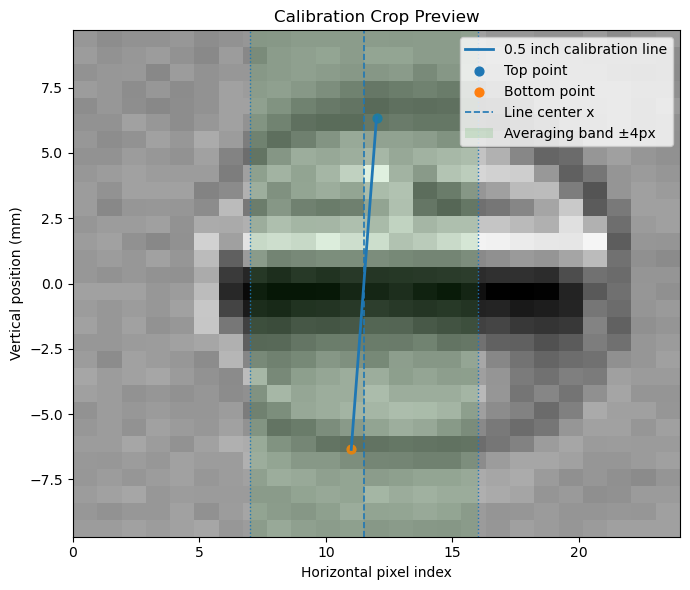

Current crop box: x=404, y=22, w=25, h=30
Adjustment conventions:
  dx_top > 0 moves top point right, dx_top < 0 moves it left
  dy_top > 0 moves top point up,    dy_top < 0 moves it down
  dx_bottom > 0 moves bottom point right, dx_bottom < 0 moves it left
  dy_bottom > 0 moves bottom point up,    dy_bottom < 0 moves it down


Shift top point x by dx_top pixels:  1
Shift top point y by dy_top pixels:  2
Shift bottom point x by dx_bottom pixels:  2
Shift bottom point y by dy_bottom pixels:  0


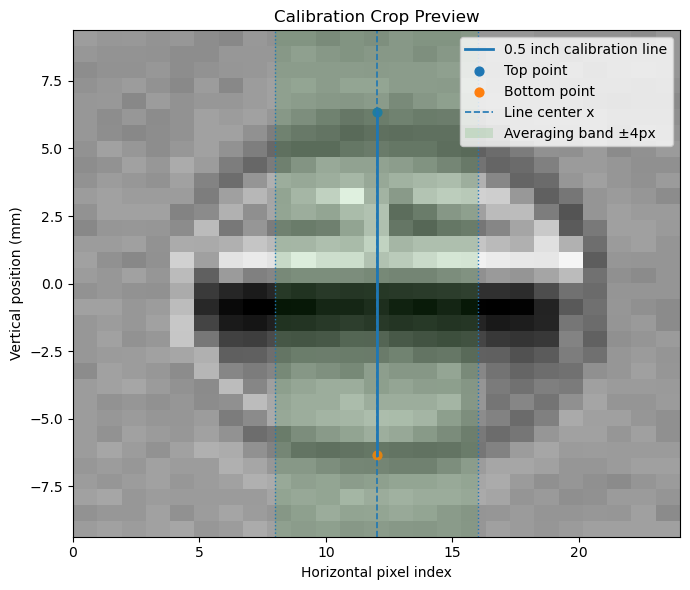

Accept this point adjustment? [y/n]:  y
Finish fine adjustment? [y/n]:  y


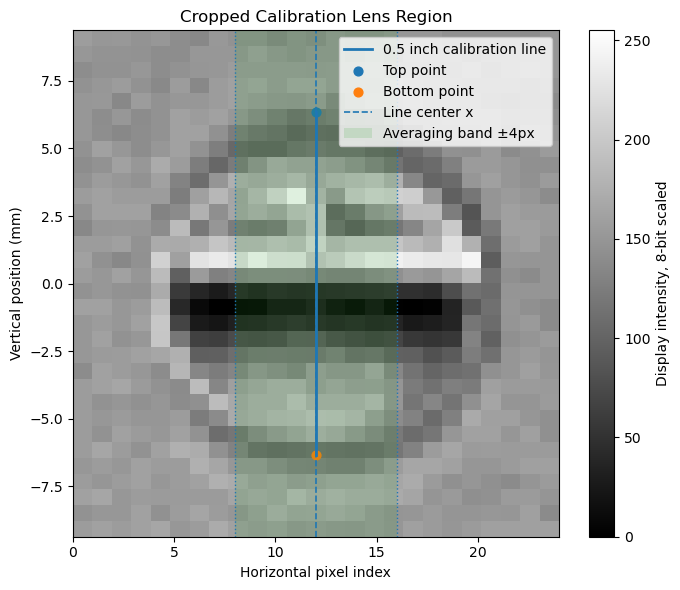

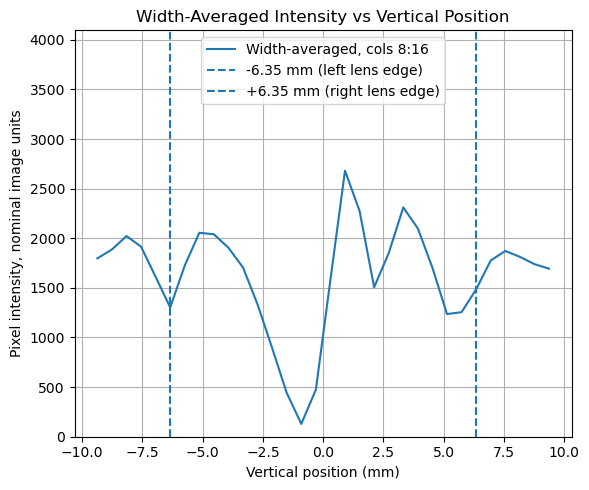

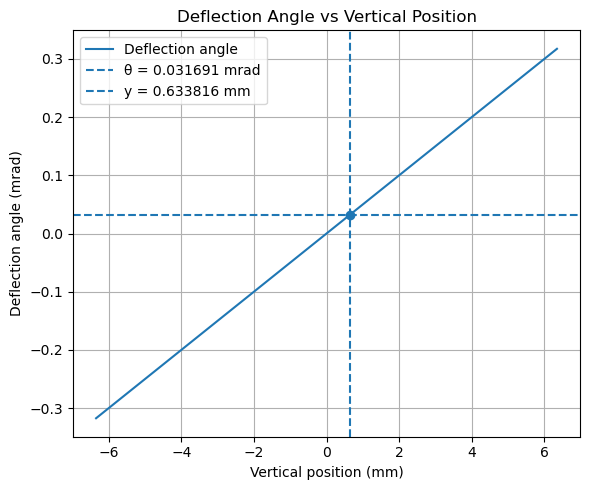

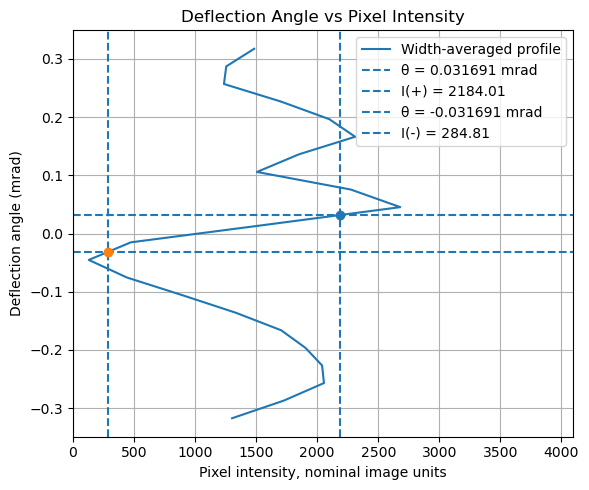

In [2]:
image_path = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED\260421007000_proc.tif"

results = analyze_calibration_lens_frame(
    image_path,
    choose_crop_interactively=True,
    known_line_height_inch=0.5,
    focal_length_mm=20000.0,
    avg_half_width_px=4,
    fine_adjust=True,
    save_cropped_path=None,
)